# 1. Estimating cetane number for diesel fuel

## 1.1. Load datasets
Importing, loading datasets and printing datasets

In [91]:
%matplotlib notebook
%matplotlib inline
import numpy as np
import matplotlib.pylab as plt
from scipy.io import loadmat
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import validation_curve
from sklearn.model_selection import learning_curve
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor

from  warnings import simplefilter
from sklearn.exceptions import ConvergenceWarning
simplefilter("ignore", category=ConvergenceWarning)

# Loading the datasets
mat = loadmat("cnDieselTrain.mat")
X_train = mat["cnTrainX"].T
y_train = mat["cnTrainY"].reshape(len(X_train))
X_test = mat["cnTestX"].T

print("X_train shape: {}".format(X_train.shape))
print("y_train shape: {}".format(y_train.shape))
print("X_test shape: {}".format(X_test.shape))
print("\n\033[1mX_train[:5, :5]:\033[0m\n{}".format(X_train[:5, :5]))
print("\n\033[1my_train[:5]:\033[0m\n{}".format(y_train[:5]))

X_train shape: (133, 401)
y_train shape: (133,)
X_test shape: (112, 401)

X_train[:5, :5]:
[[0.00619124 0.00555355 0.00491586 0.00427817 0.00364047]
 [0.00646699 0.00570776 0.00494853 0.0041893  0.00343007]
 [0.0062267  0.00550648 0.00478626 0.00406603 0.00334581]
 [0.00702172 0.00616161 0.00530151 0.0044414  0.00358129]
 [0.00582804 0.00522283 0.00461762 0.00401241 0.00340719]]

y_train[:5]:
[59.1 47.7 44.  46.9 53.6]


## 1.2. PCA, visualization, normalization
Decide the amount/which features are to be used. This is based on an analysis done on the cummulative explained variance and the explained variance from the components. The cummulated explained variance is plotted and so is the first two principal components in order to visualize the data to a certain degree for us. After looking at what we got, we decided that <b>n_components</b> should be 8 when using PCA. This is because at the <b>8th component</b> the cummulated explained variance is greater than 99% and it's the last component where the explained variance is greater than 0.1%.


Cummulative explained variance of the top [0..10]: 
[0.86214255 0.92505328 0.97219848 0.98745663 0.99224149 0.99434619
 0.99576023 0.99677507 0.99762224 0.99820923]

Explained variance in the [0..10] top features: 
[8.62142554e-01 6.29107229e-02 4.71452045e-02 1.52581507e-02
 4.78485277e-03 2.10470129e-03 1.41404267e-03 1.01484441e-03
 8.47166371e-04 5.86993201e-04]


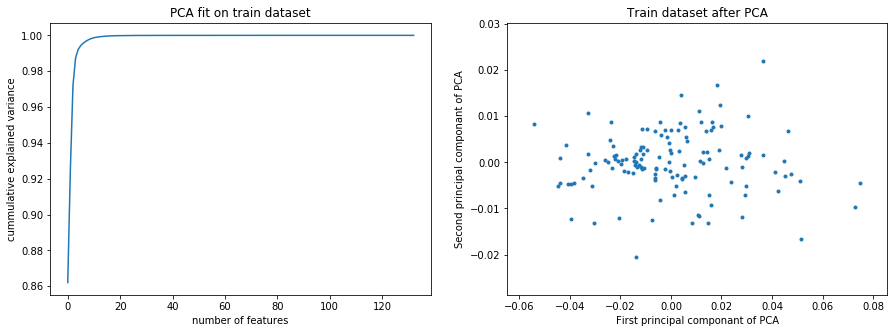

In [4]:
pca = PCA().fit(X_train)
fig1, ax1 = fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
ax1[0].plot(np.cumsum(pca.explained_variance_ratio_))
print("\n\033[1mCummulative explained variance of the top [0..10]:\033[0m \n{}".format(np.cumsum(pca.explained_variance_ratio_)[:10]))
print("\n\033[1mExplained variance in the [0..10] top features:\033[0m \n{}".format(pca.explained_variance_ratio_[:10]))
ax1[0].set_xlabel("number of features")
ax1[0].set_ylabel("cummulative explained variance")
ax1[0].set_title("PCA fit on train dataset")

X_train_pca_temp = pca.transform(X_train)
ax1[1].scatter(X_train_pca_temp[:,0], X_train_pca_temp[:,1],marker=".")
ax1[1].set_xlabel("First principal componant of PCA")
ax1[1].set_ylabel("Second principal componant of PCA")
_ = ax1[1].set_title("Train dataset after PCA")

### 1.2.1. Analyzing output from PCA transformation
Here we transform the training and test datasets using PCA to 8 components. When printing some of the data we can see that both sets need to be normalized.

In [5]:
pca = PCA(n_components=8).fit(X_train)
X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)
print("X_train_pca shape: {}\n".format(X_train_pca.shape))
print("\033[1mFirst five datapoints in 5 of the ''train'' components:\033[0m\n{}\n".format(X_train_pca[:5, :5]))

print("X_test_pca shape: {}\n".format(X_test_pca.shape))
print("\033[1mFirst five datapoints in 5 of the ''test'' components:\033[0m\n{}\n".format(X_test_pca[:5, :5]))

X_train_pca shape: (133, 8)

First five datapoints in 5 of the ''train'' components:
[[ 7.27889975e-02 -9.60923291e-03 -4.38887878e-03  1.04084543e-02
   1.78786137e-03]
 [-6.85370310e-04 -3.20798648e-05  2.36973549e-02 -9.09804558e-03
  -7.78683397e-04]
 [-3.85028971e-02 -4.48382193e-03  2.24890369e-02  5.59758662e-03
  -9.58120358e-04]
 [ 3.64705002e-02  2.20394759e-02  8.87745524e-03  6.64565873e-03
  -1.72345859e-03]
 [-7.48584925e-03 -1.25607141e-02 -1.66821388e-03 -3.58339003e-04
   1.04910844e-03]]

X_test_pca shape: (112, 8)

First five datapoints in 5 of the ''test'' components:
[[-1.13551737e-02 -5.00681211e-03 -1.91433278e-03  1.18659467e-03
  -2.03656621e-03]
 [-2.06857118e-02 -3.09705862e-03 -1.09396098e-03  1.36844543e-03
  -5.31140805e-04]
 [-2.97578932e-02 -3.57483393e-03 -9.16682543e-04  5.86579362e-03
   2.55404512e-03]
 [-1.70211802e-02 -3.49130158e-03 -9.00029613e-04 -6.60877396e-04
   3.69342527e-04]
 [ 2.27032963e-03 -8.07440427e-04 -1.53202124e-04  1.98338221e-04

### 1.2.2. Post-normalized data visualization
Here we normalize the data using <b>StandardScaler</b> fitted on the training data (X_train_pca). The transformed datasets are assigned respectively to <b>X_train_pca_scaled</b> and <b>X_test_pca_scaled</b>. After doing this we visualize the datasets with the first two principal components of PCA to see that the form is pretty similar, kind of a visual confirmation.

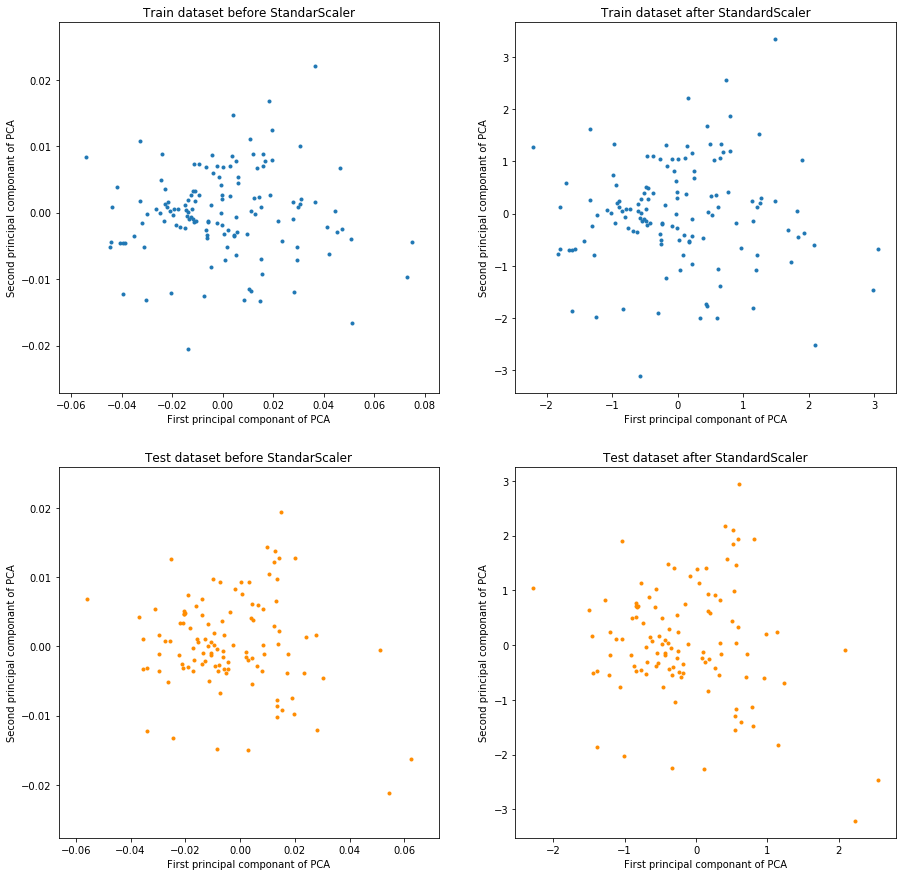

In [53]:
scaler = StandardScaler()
# fit on training data
scaler.fit(X_train_pca)
# apply transformation to training data
X_train_pca_scaled = scaler.transform(X_train_pca)
# apply same transformation to test data
X_test_pca_scaled = scaler.transform(X_test_pca)





## Plot before StandardScaler, for visualization of first and second components. TRAINING DATASET
fig2, ax2 = fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 15))
ax2[0,0].set_title("Train dataset before StandarScaler")
ax2[0,0].scatter(X_train_pca[:,0], X_train_pca[:,1],marker=".")
ax2[0,0].set_xlabel("First principal componant of PCA")
ax2[0,0].set_ylabel("Second principal componant of PCA")
## Plot after StandardScaler, for visualization of first and second components.  TRAINING DATASET
ax2[0,1].set_title("Train dataset after StandardScaler")
ax2[0,1].scatter(X_train_pca_scaled[:,0], X_train_pca_scaled[:,1],marker=".")
ax2[0,1].set_xlabel("First principal componant of PCA")
ax2[0,1].set_ylabel("Second principal componant of PCA")



## Plot before StandardScaler, for visualization of first and second components. TEST DATASET
ax2[1,0].set_title("Test dataset before StandarScaler")
ax2[1,0].scatter(X_test_pca[:,0], X_test_pca[:,1],marker=".", color="darkorange")
ax2[1,0].set_xlabel("First principal componant of PCA")
ax2[1,0].set_ylabel("Second principal componant of PCA")
## Plot after StandardScaler, for visualization of first and second components.  TEST DATASET
ax2[1,1].set_title("Test dataset after StandardScaler")
ax2[1,1].scatter(X_test_pca_scaled[:,0], X_test_pca_scaled[:,1],marker=".", color="darkorange")
ax2[1,1].set_xlabel("First principal componant of PCA")
_ = ax2[1,1].set_ylabel("Second principal componant of PCA")

## 1.3. Method and scoring
Here we choose different methods and tune the hyper-parameters with the help of <b>GridSearchCV</b>. After getting the parameters which gave us the best scoring we compare the algorithms to eachother to get the model that predicts the best. The scoring is based on MSE. CV is done 10-fold.

### 1.3.1. MLPRegressor
The first method we choose is MLPRegressor

In [7]:
# Dictionary with parameters for MLPRegressor using GridSearchCV
tuned_parameters = [{'hidden_layer_sizes':[(4,2), (9,4), (4,5), (3,3), (5,3), (3,5,3), (8,4,2)],
                     'activation':['logistic', 'relu'], 
                     'solver':['lbfgs', 'adam'],
                     'alpha':[1e-3, 1e-2, 1e-1, 1, 1e+2, 1e+2, 1e+3],
                     'learning_rate_init':[1e-3, 1e-2, 1e-1, 1, 1e+1, 1e+2],
                     'max_iter':[1000] }]

print("Training MLPRegressor, this might take a while...")
gscv = GridSearchCV( MLPRegressor(), tuned_parameters, scoring='neg_mean_squared_error', n_jobs=-1, cv=10) # n_jobs=-1 uses all cores on the CPU.
gscv.fit(X_train_pca_scaled, y_train)

print("GridSearchCV found that these parametors are the best:\n{}\n".format(gscv.best_params_))
est = gscv.best_estimator_

mean = gscv.cv_results_['mean_test_score'][gscv.best_index_]
std = gscv.cv_results_['std_test_score'][gscv.best_index_]
params = gscv.cv_results_['params'][gscv.best_index_]
print("%r\nMean: %0.3f. Std: %0.03f\n" % (params, mean, std))

After receiving the best parameters for our MLPRegressor using GridSearchCV, we plot the y_training set and predictions made on x_test set to visualize if the predictions are withing reasonable constraints. We also plot y_train set together with prediction on the x_train set to visualize if the estimator is fitting perfectly on the training data or not. And as we see for all the 8 components of PCA, the data seems reasonable, not fitting the training data perfect but not too bad either and when looking at the prediction on the test data.

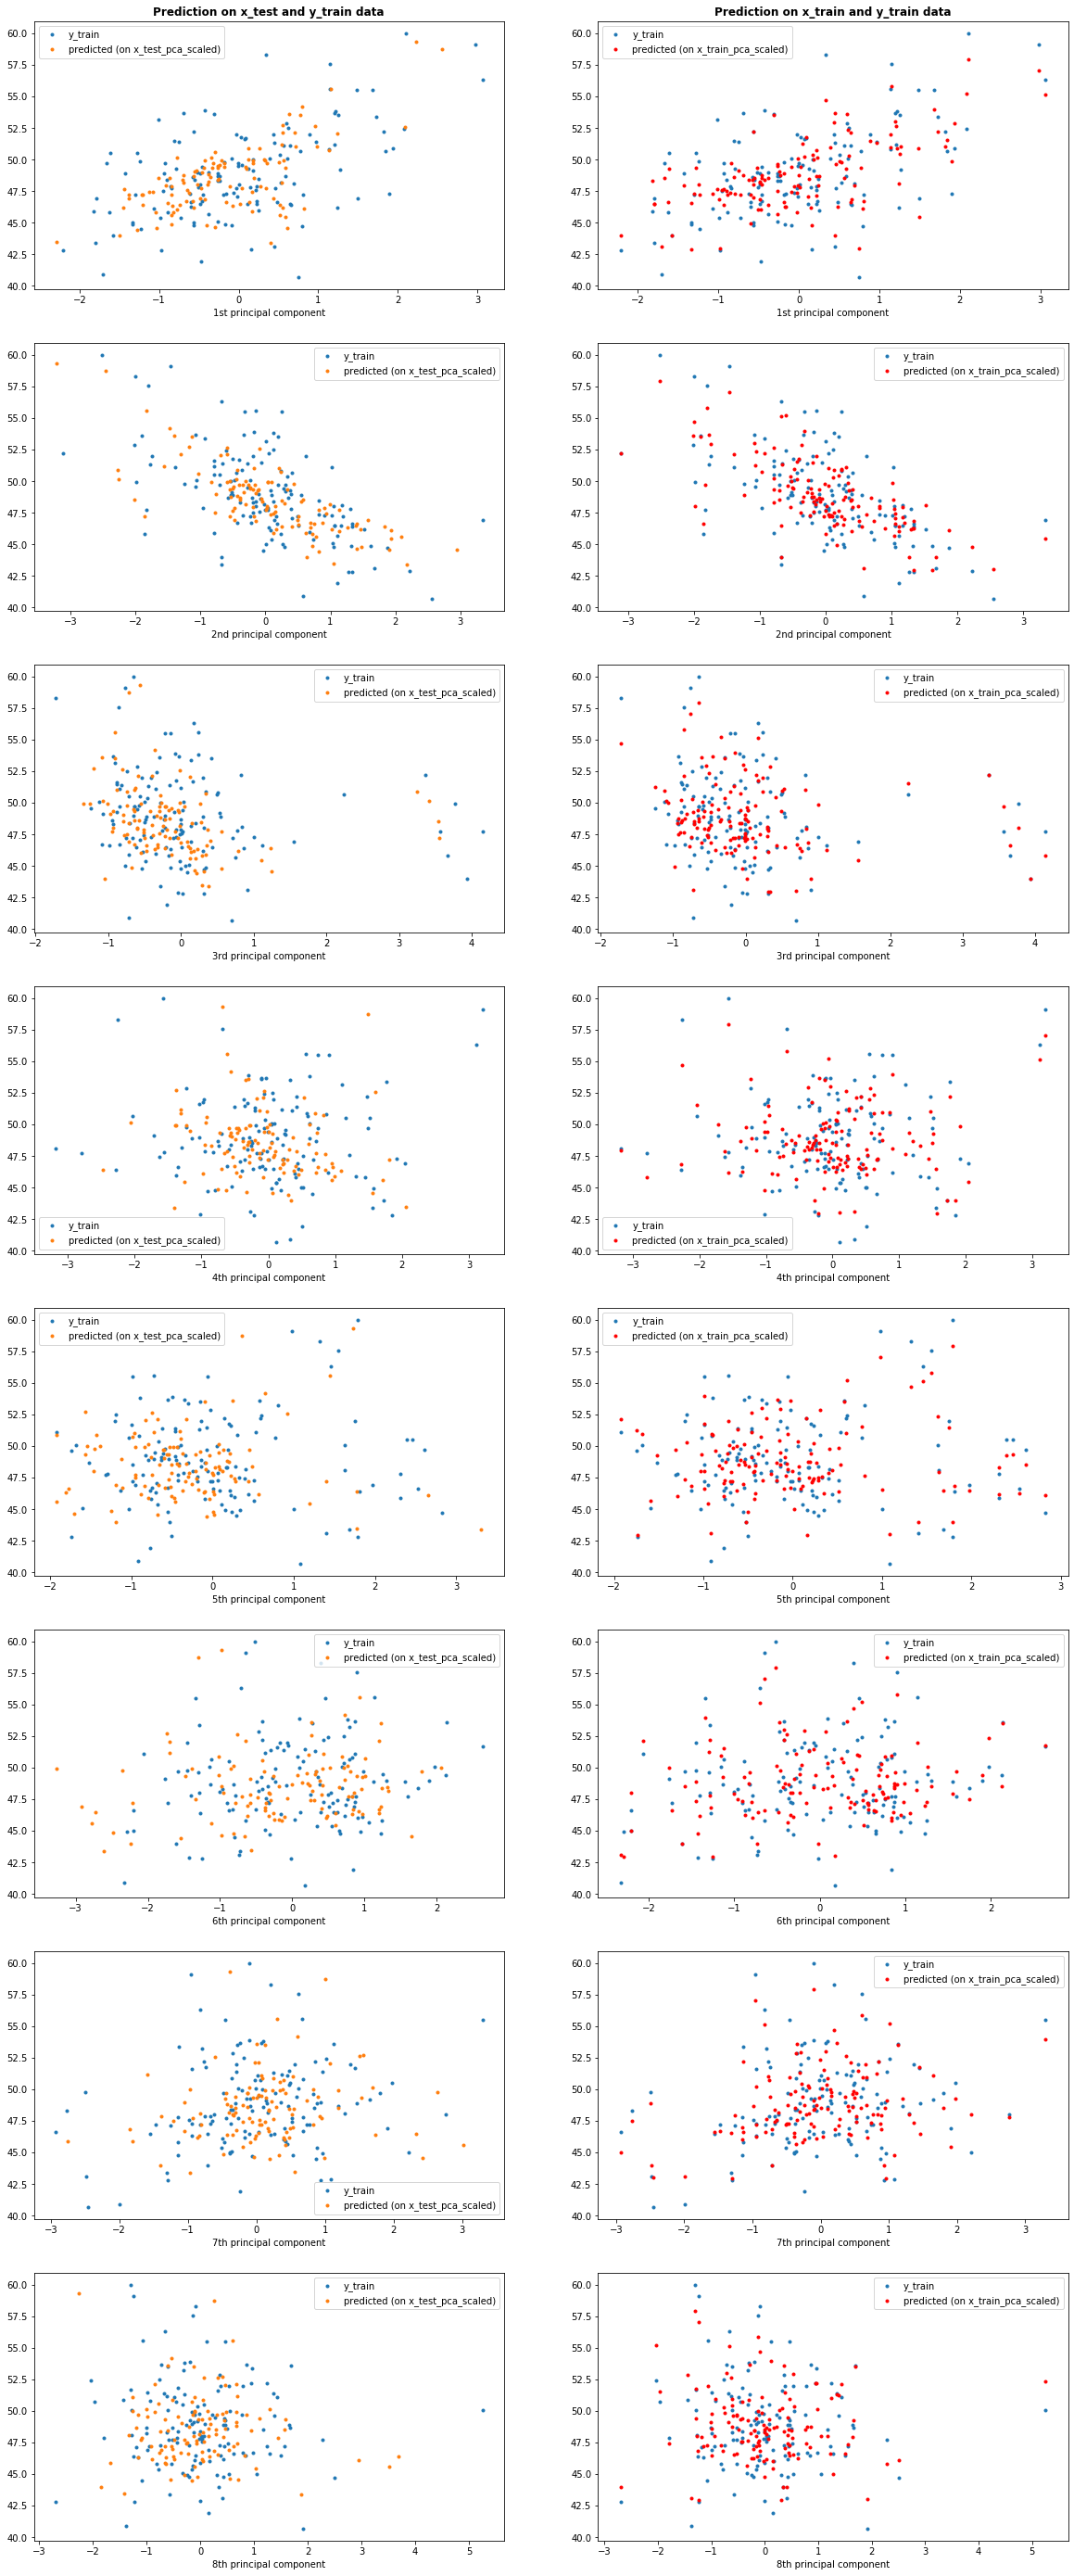

In [50]:
#cv_score_mse = cross_val_score(est, X_train_pca_scaled, y_train, cv=10, scoring = 'neg_mean_squared_error')
#print("%0.3f (+/- %0.03f)" % (cv_score_mse.mean(), cv_score_mse.std()))

x_test_predicted = est.predict(X_test_pca_scaled)
x_train_predicted = est.predict(X_train_pca_scaled)

nrows=8
ncols=2
fig4, ax4 = fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, 50))
ax4[0,0].scatter(X_train_pca_scaled[:, 0], y_train, marker=".", label="y_train")
ax4[0,0].scatter(X_test_pca_scaled[:, 0], x_test_predicted, marker=".", label="predicted (on x_test_pca_scaled)")

ax4[0,1].scatter(X_train_pca_scaled[:, 0], y_train, marker=".", label="y_train")
ax4[0,1].scatter(X_train_pca_scaled[:, 0], x_train_predicted, marker=".", color="red", label="predicted (on x_train_pca_scaled)")

ax4[0,0].set_xlabel("1st principal component")
ax4[0,1].set_xlabel("1st principal component")

ax4[0,0].set_title("Prediction on x_test and y_train data", fontweight='bold')
ax4[0,1].set_title("Prediction on x_train and y_train data", fontweight='bold')

ax4[0,0].legend(loc="best")
ax4[0,1].legend(loc="best")

##################################################################################################################################################################
##########     Same method for the first 3 subplots and a for-loop for the rest (because of english grammar -> 1st, 2nd, 3rd, 4th ... 11th ... Xth)     ##########
##################################################################################################################################################################
ax4[1,0].scatter(X_train_pca_scaled[:, 1], y_train, marker=".", label="y_train")
ax4[1,0].scatter(X_test_pca_scaled[:, 1], x_test_predicted, marker=".", label="predicted (on x_test_pca_scaled)")
ax4[1,1].scatter(X_train_pca_scaled[:, 1], y_train, marker=".", label="y_train")
ax4[1,1].scatter(X_train_pca_scaled[:, 1], x_train_predicted, marker=".", color="red", label="predicted (on x_train_pca_scaled)")
ax4[1,0].set_xlabel("2nd principal component")
ax4[1,1].set_xlabel("2nd principal component")
ax4[1,0].legend(loc="best")
ax4[1,1].legend(loc="best")
ax4[2,0].scatter(X_train_pca_scaled[:, 2], y_train, marker=".", label="y_train")
ax4[2,0].scatter(X_test_pca_scaled[:, 2], x_test_predicted, marker=".", label="predicted (on x_test_pca_scaled)")
ax4[2,1].scatter(X_train_pca_scaled[:, 2], y_train, marker=".", label="y_train")
ax4[2,1].scatter(X_train_pca_scaled[:, 2], x_train_predicted, marker=".", color="red", label="predicted (on x_train_pca_scaled)")
ax4[2,0].set_xlabel("3rd principal component")
ax4[2,1].set_xlabel("3rd principal component")
ax4[2,0].legend(loc="best")
ax4[2,1].legend(loc="best")
for row in range(3, nrows):
    ax4[row,0].scatter(X_train_pca_scaled[:, row], y_train, marker=".", label="y_train")
    ax4[row,0].scatter(X_test_pca_scaled[:, row], x_test_predicted, marker=".", label="predicted (on x_test_pca_scaled)")

    ax4[row,1].scatter(X_train_pca_scaled[:, row], y_train, marker=".", label="y_train")
    ax4[row,1].scatter(X_train_pca_scaled[:, row], x_train_predicted, marker=".", color="red", label="predicted (on x_train_pca_scaled)")

    ax4[row,0].set_xlabel(str(row+1) + "th principal component")
    ax4[row,1].set_xlabel(str(row+1) + "th principal component")
    
    ax4[row,0].legend(loc="best")
    ax4[row,1].legend(loc="best")

plt.show()

Here we plot learning curve to see if we overfit or underfit. As the training examples grow we see that we overfit and underfitt less. The model looks pretty good.

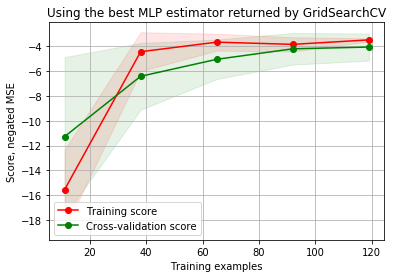

In [106]:
train_sizes, train_scores, test_scores = learning_curve(est, X_train_pca_scaled, y_train, cv=10, scoring='neg_mean_squared_error', n_jobs=-1)

train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

#print("%0.3f (+/- %0.03f)" % (test_scores_mean[-1], test_scores_std[-1]))

plt.title("Using the best MLP estimator returned by GridSearchCV")
plt.xlabel("Training examples")
plt.ylabel("Score, negated MSE")
plt.grid()
plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color="r")
plt.fill_between(train_sizes, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, alpha=0.1, color="g")
plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")
plt.legend(loc="best")
plt.show()

### 1.3.2. Random Forest Regressor
The second method we choose is Random Forest Regressor.

In [107]:
# Dictionary with parameters for RandomForestRegressor using GridSearchCV
tuned_parameters = [{'n_estimators':[5, 10, 20, 50, 100, 200],
                     'criterion':['mse'], 
                     'min_samples_split':[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
                     'min_samples_leaf':[1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
                     'n_jobs':[-1],
                     'max_samples':[0.3, 0.5, 0.7, 0.9] }]

print("Training RandomForestRegressor, this might take a while...")
gscv = GridSearchCV( RandomForestRegressor(), tuned_parameters, scoring='neg_mean_squared_error', n_jobs=-1, cv=10) # n_jobs=-1 uses all cores on the CPU.
gscv.fit(X_train_pca_scaled, y_train)

print("GridSearchCV found that these parametors are the best:\n{}\n".format(gscv.best_params_))
rfr_est = gscv.best_estimator_

mean = gscv.cv_results_['mean_test_score'][gscv.best_index_]
std = gscv.cv_results_['std_test_score'][gscv.best_index_]
params = gscv.cv_results_['params'][gscv.best_index_]
print("Mean: %0.3f. Std: %0.03f\n" % (mean, std))

Training RandomForestRegressor, this might take a while...
GridSearchCV found that these parametors are the best:
{'criterion': 'mse', 'max_samples': 0.9, 'min_samples_leaf': 3, 'min_samples_split': 0.1, 'n_estimators': 50, 'n_jobs': -1}


Mean: -5.919. Std: 2.480

